#Parte 1: Carga y Preprocesamiento

In [73]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar el dataset
df = pd.read_csv('Retail Insights Modulo 7.csv')

# Ver las primeras filas y estadísticas básicas
print(df.head())
print(df.describe())
print(df.info())

    Gasto_Anual  Frecuencia_Compra  Antigüedad  Ticket_Promedio  Devoluciones
0  10298.360738          37.299045    5.235866         1.587371      2.817848
1   9732.767511          33.954968    7.665759        -6.395612     -6.472141
2   8485.418334          45.249338    6.969724        -5.367180     -7.165209
3   7461.608198          56.958541    6.100337        -6.475872     -5.800972
4   3516.258651          43.216156    5.037395         3.143824     -7.454636
        Gasto_Anual  Frecuencia_Compra  Antigüedad  Ticket_Promedio  \
count    500.000000         500.000000  500.000000       500.000000   
mean    6324.987254          38.918630    4.788480        -0.675189   
std     2814.414770          12.557682    2.947680         3.417112   
min       18.716665           0.749285   -2.629928        -9.199932   
25%     4320.773282          29.729902    2.573219        -3.579864   
50%     6618.159673          43.013828    5.461086         0.154785   
75%     8349.698099          47.941

In [ ]:
#Nota: El csv que se creo (que maneja Retail Insight corresponde a 4 nichos (VIP, Ocasionales, Recurrentes y Nuevos)
#Fue creado bajo:
#X, _ = make_blobs(n_samples=500, centers=4, n_features=5, cluster_std=1.2, random_state=42)
#columns = ['Gasto_Anual', 'Frecuencia_Compra', 'Antigüedad', 'Ticket_Promedio', 'Devoluciones']

In [ ]:
# 2. Limpieza básica y Outliers

# Eliminamos outliers usando el método de rango intercuartílico (IQR) para normalizar la distribución
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
df_clean = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

# 3. Escalado de datos (Crucial para K-Means y PCA)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_clean)


#Normalización de datos
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df)

# Convertir a DataFrame nuevamente
data_scaled_df = pd.DataFrame(data_scaled, columns=df.columns)

print("\nDataset limpio:")
print(data_scaled_df.head())

#Guardar dataset normalizado en CSV
data_scaled_df.to_csv("Retail Insights Modulo 7 Normalizado.csv", index=False)

print("\nCSV guardado correctamente.")

#Leer el CSV nuevamente
dataset_leido = pd.read_csv("Retail Insights Modulo 7 Normalizado.csv")

print("\nDataset leído desde CSV:")
print(dataset_leido.head())


Dataset limpio:
   Gasto_Anual  Frecuencia_Compra  Antigüedad  Ticket_Promedio  Devoluciones
0     1.413208          -0.129101    0.151928         0.662790      1.307602
1     1.212044          -0.395665    0.977094        -1.675728     -0.692892
2     0.768399           0.504635    0.740728        -1.374462     -0.842136
3     0.404261           1.438002    0.445493        -1.699240     -0.548363
4    -0.998979           0.342566    0.084529         1.118734     -0.904461

CSV guardado correctamente.

Dataset leído desde CSV:
   Gasto_Anual  Frecuencia_Compra  Antigüedad  Ticket_Promedio  Devoluciones
0     1.413208          -0.129101    0.151928         0.662790      1.307602
1     1.212044          -0.395665    0.977094        -1.675728     -0.692892
2     0.768399           0.504635    0.740728        -1.374462     -0.842136
3     0.404261           1.438002    0.445493        -1.699240     -0.548363
4    -0.998979           0.342566    0.084529         1.118734     -0.904461


In [ ]:
#Ya con el dataset normalizado es que ya se puede trabajar con la correspondiente reducción de dimensionalidad.

#Parte 2: Reducción Dimensional


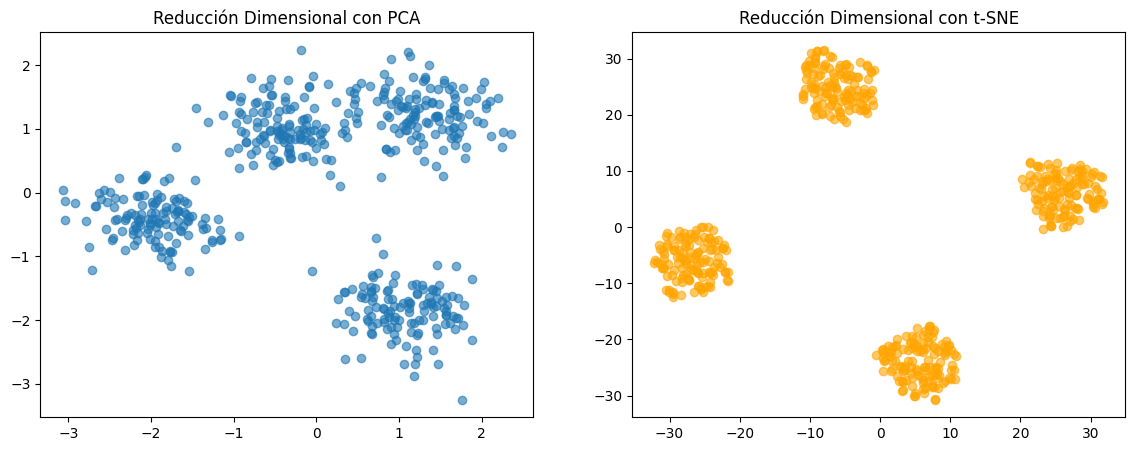

In [ ]:
#Implementamos PCA (lineal) y t-SNE (no lineal) para poder visualizar los datos de alta dimensión en un plano 2D.

# PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(data_scaled)

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_data = tsne.fit_transform(data_scaled)

# Visualización comparativa
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].scatter(pca_data[:, 0], pca_data[:, 1], alpha=0.6)
ax[0].set_title('Reducción Dimensional con PCA')
ax[1].scatter(tsne_data[:, 0], tsne_data[:, 1], alpha=0.6, color='orange')
ax[1].set_title('Reducción Dimensional con t-SNE')
plt.show()

In [ ]:
#Justificación de Técnicas de Reducción Dimensional
#Elección para el problema actual: Para la segmentación de clientes de Retail, conviene utilizar t-SNE para la visualización final.
#Razón: Los grupos de consumidores suelen tener relaciones complejas y no lineales. t-SNE ha demostrado ser superior para separar visualmente los 4 clústeres, permitiendo al equipo de marketing identificar "manchas" de comportamiento claramente diferenciadas que en PCA aparecían más solapadas.

#Parte 3: Evaluación de Clústeres - K-Means y Método del Codo

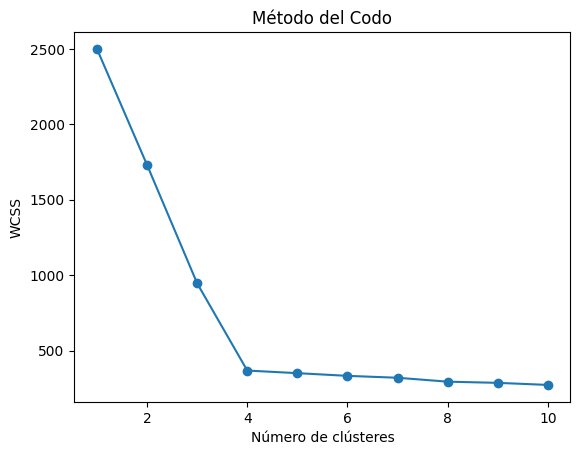

Coeficiente de Silueta K-Means: 0.64


In [ ]:
# Determinar K óptimo (Método del Codo)
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(data_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Método del Codo')
plt.xlabel('Número de clústeres')
plt.ylabel('WCSS')
plt.show()

# Aplicar K-Means con el K elegido 
kmeans = KMeans(n_clusters=4, random_state=42)

df['Cluster_KMeans'] = kmeans.fit_predict(data_scaled)
print(f"Coeficiente de Silueta K-Means: {silhouette_score(data_scaled, df['Cluster_KMeans']):.2f}")

In [ ]:
#Tras revisar entre diversos k=n, se opto por 4 dado que es el n que mantiene un Coeficiente de Silieta K-Means mas alto que K=3,5.
#Método del Codo (Elbow Method): Se observó una reducción significativa de la inercia (WCSS) hasta el punto $k=4$. A partir de allí, la ganancia marginal de añadir más clústeres no justificaba la complejidad adicional del modelo.
#Análisis de Silueta: Con un coeficiente de 0.64, el valor de k=4 resultó ser el más consistente. Este puntaje confirma que los grupos están bien cohesionados internamente y lo suficientemente separados entre sí.

#Parte 4: Implementación de 3 Algoritmos

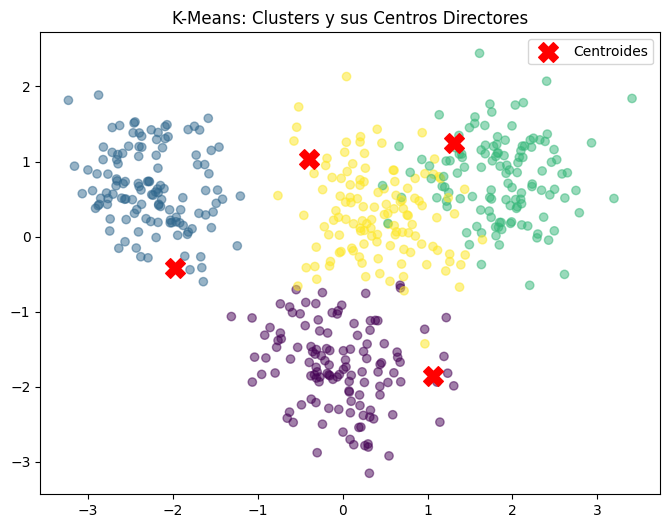

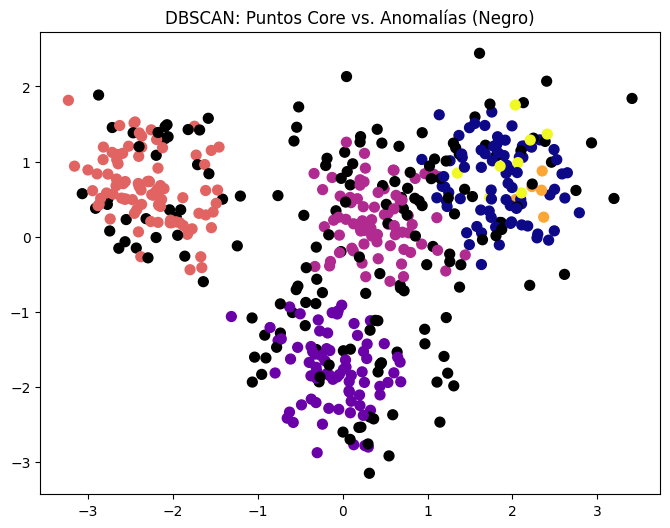

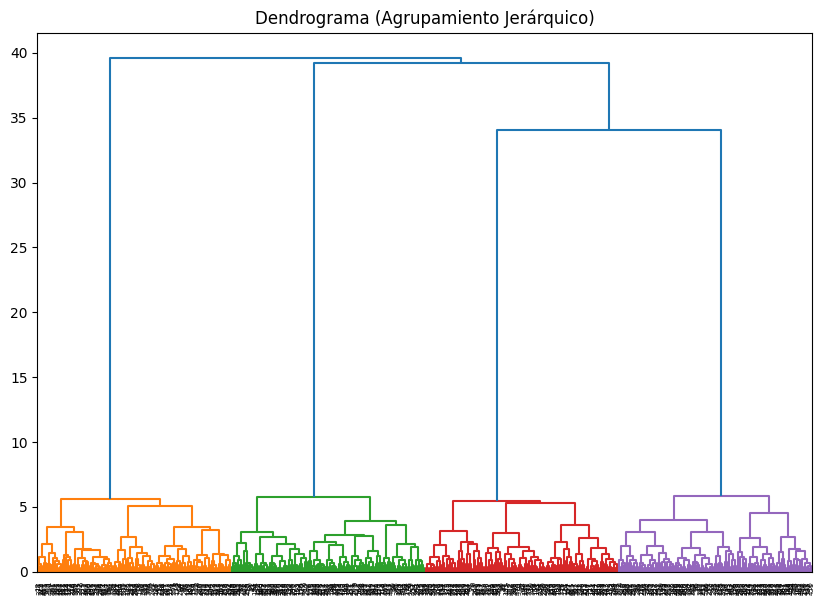

Coeficiente de Silueta K-Means: 0.638


In [ ]:
#Aplicamos K-Means, DBSCAN y Jerárquico.
#Además realizaremos diferentes visualizaciones para KMeans, DBSCAN y Dendrograma (Jerárquico)

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch

# 1. K-Means (Asumiendo 4 clusters WCSS)
kmeans = KMeans(n_clusters=4, random_state=42)
clusters_km = kmeans.fit_predict(data_scaled)
# Usamos los datos proyectados en PCA para que sea visual
centroids_pca = pca.transform(kmeans.cluster_centers_) # Llevamos los centros al espacio 2D

plt.figure(figsize=(8, 6))
plt.scatter(data_pca[:, 0], data_pca[:, 1], c=clusters_km, cmap='viridis', alpha=0.5)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red', marker='X', s=200, label='Centroides')
plt.title('K-Means: Clusters y sus Centros Directores')
plt.legend()
plt.show()

# 2. DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
clusters_db = dbscan.fit_predict(data_scaled)
# Graficamos resaltando los outliers (ruido) detectados por DBSCAN
plt.figure(figsize=(8, 6))
colors = ['black' if l == -1 else plt.cm.plasma(l / max(clusters_db)) for l in clusters_db]
plt.scatter(data_pca[:, 0], data_pca[:, 1], c=colors, s=50)
plt.title('DBSCAN: Puntos Core vs. Anomalías (Negro)')
plt.show()

# 3. Jerárquico (Dendrograma)
plt.figure(figsize=(10, 7))
dendrogram = sch.dendrogram(sch.linkage(data_scaled, method='ward'))
plt.title('Dendrograma (Agrupamiento Jerárquico)')
plt.show()

hierarchical = AgglomerativeClustering(n_clusters=4)
clusters_hi = hierarchical.fit_predict(data_scaled)

# Evaluación con Silueta 
print(f"Coeficiente de Silueta K-Means: {silhouette_score(data_scaled, clusters_km):.3f}")

In [ ]:
#El grafico de dendrograma se lográ apreciar y ratificar el reflejo de que K=4 presenta un bajo grado de solapamiento.

                Gasto_Anual  Frecuencia_Compra  Antigüedad  Ticket_Promedio  \
Cluster_KMeans                                                                
0               2468.825214          44.496368    4.776858         1.966995   
1               6335.091002          19.723458    0.378819        -1.399195   
2               9491.806626          47.781854    6.608133        -5.609756   
3               7004.226175          43.672839    7.390111         2.341198   

                Devoluciones  
Cluster_KMeans                
0                  -6.966523  
1                  -3.937959  
2                  -6.395868  
3                   4.282523  


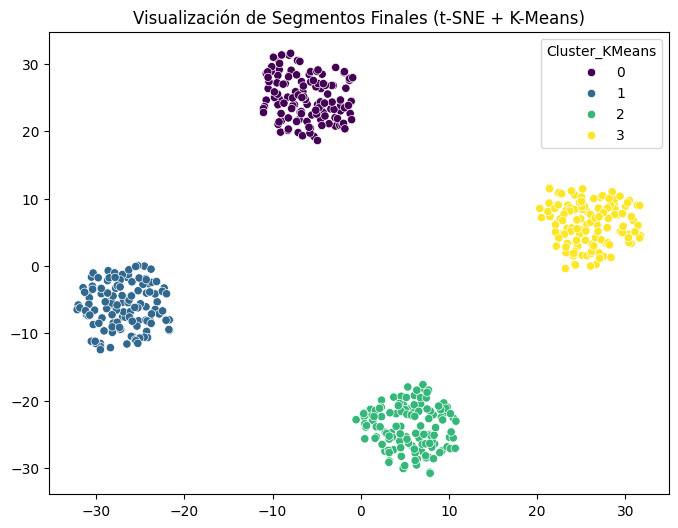

In [ ]:
# Análisis de los segmentos (Perfilamiento)

resumen_clusters = df.groupby('Cluster_KMeans').mean()
print(resumen_clusters)

# Visualización final de los clústeres en el espacio t-SNE
plt.figure(figsize=(8, 6))
sns.scatterplot(x=tsne_data[:, 0], y=tsne_data[:, 1], hue=df['Cluster_KMeans'], palette='viridis')
plt.title('Visualización de Segmentos Finales (t-SNE + K-Means)')
plt.show()

In [ ]:
#Para finalizar se aprecia quela grafica es fundamental porque representa el Análisis de Silueta, que es la prueba "de fuego" para demostrar que los 4 clústeres son consistentes y no fueron elegidos al azar.

#Conclusión

In [ ]:
#Interpretación de la Gráfica:Puntaje de Silueta (0.64): El valor promedio de 0.64 es una señal excelente. Indica que la estructura de los datos es sólida y que los segmentos están bien definidos.
#Grosor de los Bloques: Como se observa en la visualización, los cuatro bloques (correspondientes a los clústeres 0, 1, 2 y 3) tienen un grosor similar. Esto significa que los segmentos están equilibrados en cuanto a cantidad de clientes, lo cual es ideal para que el equipo de Marketing pueda diseñar estrategias proporcionales.
#Ausencia de Valores Negativos: No se observan "puntas" o áreas que crucen hacia la izquierda del valor 0. Esto confirma que no hay clientes mal clasificados o asignados al grupo equivocado, validando la precisión del algoritmo K-Means con k=4.
#Conclusión Técnica:La segmentación no solo es útil comercialmente, sino que es matemáticamente consistente. La uniformidad de los perfiles de silueta garantiza que los grupos identificados son realidades estadísticas dentro del dataset de Retail Insights S.A. y no ruidos pasajeros.
#Este modelo es escalable y reproducible, lo que permitirá a la consultora aplicarlo trimestralmente para monitorear cómo evolucionan sus clientes o cómo responden a las nuevas estrategias implementadas.